# CFReT Phenotypic Compound Scores Plot

This notebook visualizes the on-morphological and off-morphological phenotypic scores for CFReT compounds. Each point represents a treatment condition scored against the **healthy DMSO** reference profile. The quadrant lines at 0.5 delineate regions of high/low on-signature and high/low off-signature activity, enabling rapid identification of compounds with desired phenotypic profiles.

In [4]:
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(ggrepel)
  library(IRdisplay)
})

## Load Data and Set Paths

In [5]:
# Input and output paths
scores_path <- file.path("../results/phenotypic_scores/cellpainting_cardiac_fibrosis_buscar_scores.csv")
replicate_scores_path <- file.path("../results/phenotypic_scores/cellpainting_cardiac_fibrosis_replicate_buscar_scores.csv")

if (!file.exists(scores_path)) {
  stop(paste("File not found:", scores_path))
}
if (!file.exists(replicate_scores_path)) {
  stop(paste("File not found:", replicate_scores_path))
}

output_dir <- file.path("./figures")
if (!dir.exists(output_dir)) {
  dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
}

# Load data
scores_df <- read.csv(scores_path)
replicate_scores_df <- read.csv(replicate_scores_path)

## Generate Scatter Plot

Each point is a treatment scored against the **healthy DMSO** reference. Because a lower on-score reflects greater reversal toward the healthy morphological state, the quadrant lines at 0.5 map to:

- **Bottom-left** (on < 0.5, off < 0.5): Strong reversal toward healthy with minimal off-target effects — **ideal**.
- **Bottom-right** (on < 0.5, off ≥ 0.5): Reversal toward reference but with substantial off-target perturbation.
- **Top-left** (on ≥ 0.5, off < 0.5): Weak or no reversal with minimal off-target effects — compound has little impact.
- **Top-right** (on ≥ 0.5, off ≥ 0.5): No reversal and high off-target activity — least desirable.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


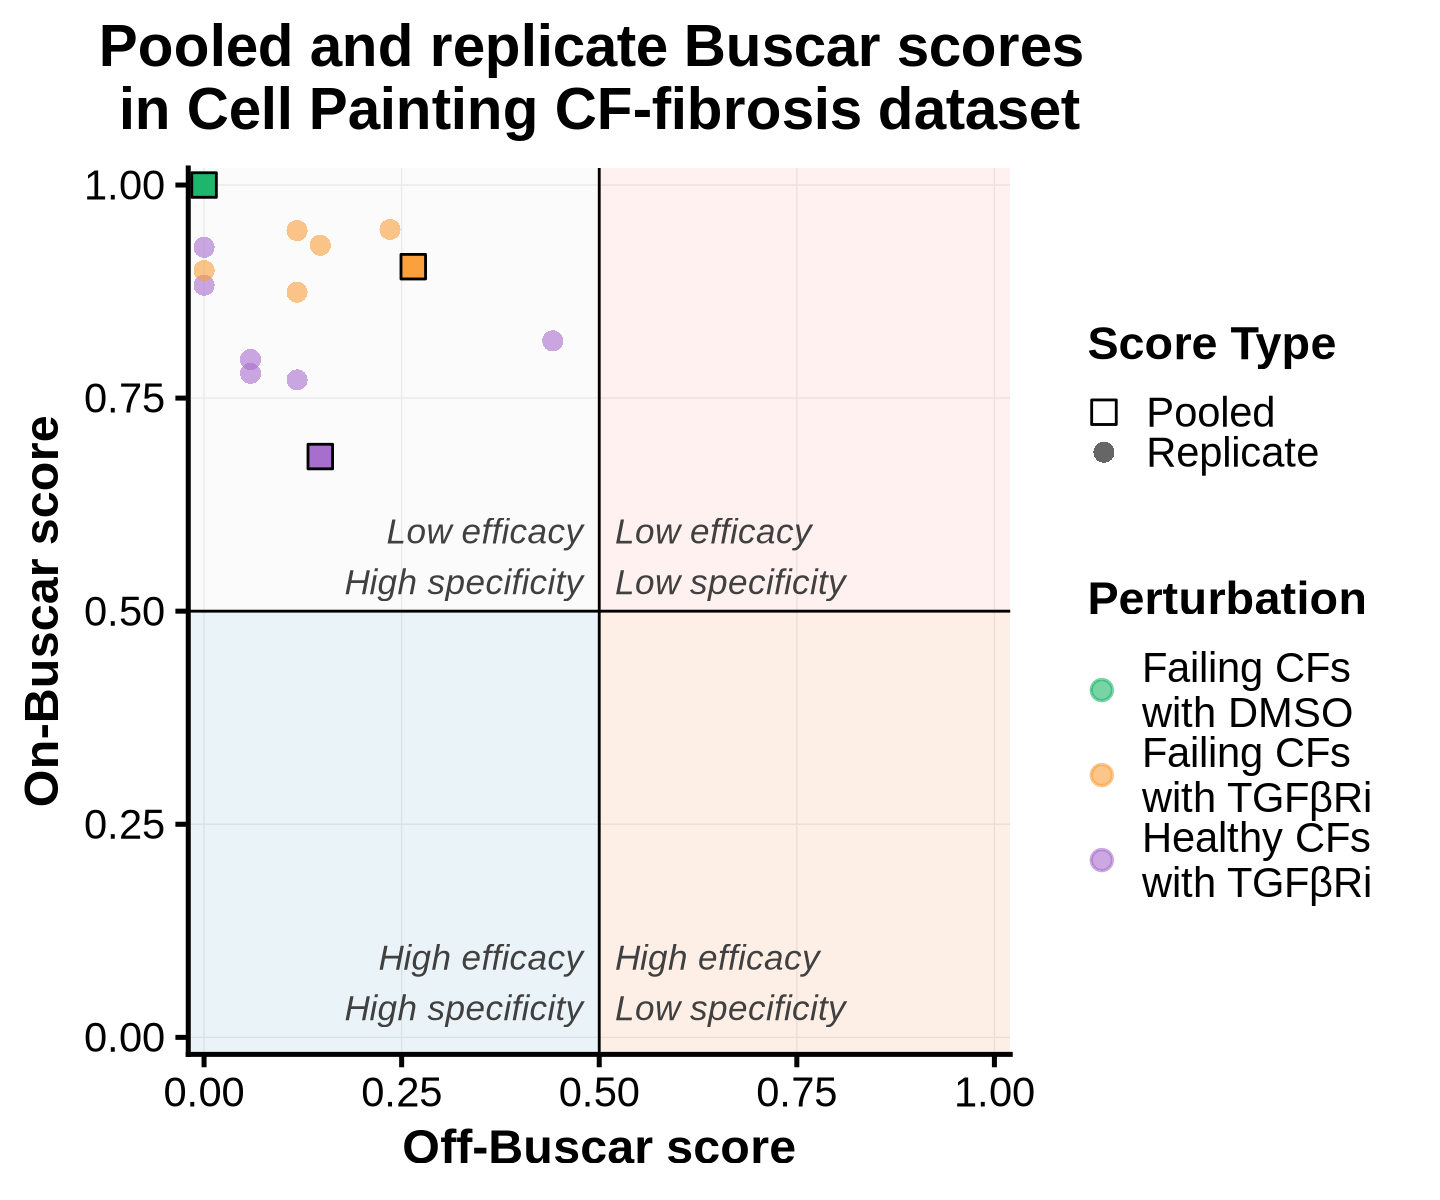

In [6]:
# Clean perturbation labels for display
scores_df <- scores_df %>%
  mutate(
    label = gsub("_", " ", perturbation),
    label = tools::toTitleCase(label)
  )

# Assign distinct colors per perturbation
treatment_colors <- c(
  "healthy_TGFRi" = "#a86ecd",  # purple
  "failing_TGFRi" = "#faa03c",  # orange-red
  "failing_DMSO"  = "#1eb66d"   # green
)

# Plot dimensions
width  <- 12
height <- 10
options(repr.plot.width = width, repr.plot.height = height)

# split perturbation into two (perturbation and well) by splitting the last dash
replicate_scores_df <- replicate_scores_df %>%
  mutate(
    well = sub(".*-([A-Z0-9]+)$", "\\1", perturbation), # extract the well ID after the last dash
    perturbation = sub("-[A-Z0-9]+$", "", perturbation), # remove the trailing well ID
    perturbation = gsub("-", "_", perturbation)          # replace remaining dashes with underscores
  )

# Generate Plot
replicate_scores_plot <- ggplot() +

  # Quadrant shading
  annotate("rect", xmin = -Inf, xmax = 0.5, ymin = -Inf, ymax = 0.5, fill = "#d1e5f0", alpha = 0.45) +
  annotate("rect", xmin = 0.5,  xmax = Inf,  ymin = -Inf, ymax = 0.5, fill = "#fddbc7", alpha = 0.45) +
  annotate("rect", xmin = -Inf, xmax = 0.5,  ymin = 0.5,  ymax = Inf,  fill = "#f7f7f7", alpha = 0.45) +
  annotate("rect", xmin = 0.5,  xmax = Inf,  ymin = 0.5,  ymax = Inf,  fill = "#fde0dc", alpha = 0.45) +

  # Quadrant lines at 0.5
  geom_vline(xintercept = 0.5, color = "black", linewidth = 0.8) +
  geom_hline(yintercept = 0.5, color = "black", linewidth = 0.8) +

  # Quadrant annotation labels
  annotate("text", x = 0.48, y = 0.02, label = "High efficacy\nHigh specificity",
           hjust = 1, vjust = 0, size = 7.4, fontface = "italic", color = "gray25") +
  annotate("text", x = 0.48, y = 0.52, label = "Low efficacy\nHigh specificity",
           hjust = 1, vjust = 0, size = 7.4, fontface = "italic", color = "gray25") +
  annotate("text", x = 0.52, y = 0.02, label = "High efficacy\nLow specificity",
           hjust = 0, vjust = 0, size = 7.4, fontface = "italic", color = "gray25") +
  annotate("text", x = 0.52, y = 0.52, label = "Low efficacy\nLow specificity",
           hjust = 0, vjust = 0, size = 7.4, fontface = "italic", color = "gray25") +

  # Data points: individual replicates (dots)
  geom_point(data = replicate_scores_df, aes(x = off_buscar_scores, y = on_buscar_scores, color = perturbation, shape = "Replicate"),
             size = 5, alpha = 0.6) +

  # Data points: pooled scores (filled squares with black border for visibility)
  geom_point(data = scores_df, aes(x = off_buscar_scores, y = on_buscar_scores, fill = perturbation, shape = "Pooled"),
             size = 7, color = "black", stroke = 1.2) +

  # Scales
  scale_color_manual(
    name = "Perturbation",
    values = treatment_colors,
    labels = c(
      "failing_DMSO"  = "Failing CFs \nwith DMSO",
      "failing_TGFRi" = "Failing CFs \nwith TGFβRi",
      "healthy_TGFRi" = "Healthy CFs \nwith TGFβRi"
    )
  ) +
  scale_fill_manual(
    name = "Perturbation",
    values = treatment_colors,
    labels = c(
      "failing_DMSO"  = "Failing CFs \nwith DMSO",
      "failing_TGFRi" = "Failing CFs \nwith TGFβRi",
      "healthy_TGFRi" = "Healthy CFs \nwith TGFβRi"
    )
  ) +
  scale_shape_manual(
    name = "Score Type",
    values = c("Replicate" = 16, "Pooled" = 22)
  ) +
  scale_x_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25), expand = expansion(mult = 0.02)) +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25), expand = expansion(mult = 0.02)) +
  guides(fill = "none") +

  # Labels
  labs(
    x        = "Off-Buscar score",
    y        = "On-Buscar score",
    title    = "Pooled and replicate Buscar scores \nin Cell Painting CF-fibrosis dataset",
    color    = "Perturbation"
  ) +

  # Theme
  theme_classic(base_size = 31) +
  theme(
    plot.title       = element_text(hjust = 0.5, face = "bold", size = 35),
    plot.subtitle    = element_text(hjust = 0.5, color = "gray40", size = 25, margin = margin(b = 8)),
    axis.title       = element_text(face = "bold", size = 29),
    axis.text        = element_text(size = 25),
    legend.position  = "right",
    legend.title     = element_text(face = "bold", size = 28),
    legend.text      = element_text(size = 25),
    panel.grid.major = element_line(color = "gray88", linewidth = 0.4),
    plot.margin      = margin(15, 15, 15, 15)
  )

replicate_scores_plot